# Decission tree

# 1 Importar librerias

In [1]:
import os
import requests
import pickle
from joblib import dump
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, export_text
from pickle import dump
from sklearn.tree import plot_tree
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import shap
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

KeyboardInterrupt: 

# 2. Abrir csv

In [ ]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/diabetes.csv")
# Fijar el id como indice
pd.set_option('display.max_columns', None)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 3. Cribado manual

## 3.1 Columnas con valores únicos

In [ ]:
unicos = df.nunique()
df[unicos[unicos == 1].index]

""
0
1
2
3
4
...
763
764
765
766


## 3.2 Visualizar valores duplicados

### Filas

In [ ]:
filas_dupli = df.duplicated()
df[filas_dupli]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### Columnas

In [ ]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 3.3 Valores 0 a NaN

In [ ]:
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

## 3.4 Datos faltantes

In [ ]:
missing=df.isna().mean()*100
missing[missing>0]

Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64

In [ ]:
missing_per_row = df.isna().sum(axis=1)
(missing_per_row >= 3).sum()

np.int64(35)

In [ ]:
df = df[missing_per_row < 3] # Se eliminan los anteriores 

Dado que la eliminación indiscriminada de filas puede resultar demasiado agresiva, se optó por eliminar únicamente aquellas observaciones que contenían tres o más valores faltantes, ya que su nivel de incompletitud dificulta una imputación fiable.

In [ ]:
fila_datos_faltantes = df.isna().any(axis=1).sum() # any sirve para ver CUALQUIER dato faltante
fila_datos_faltantes[fila_datos_faltantes>0]

array([341])

<Axes: >

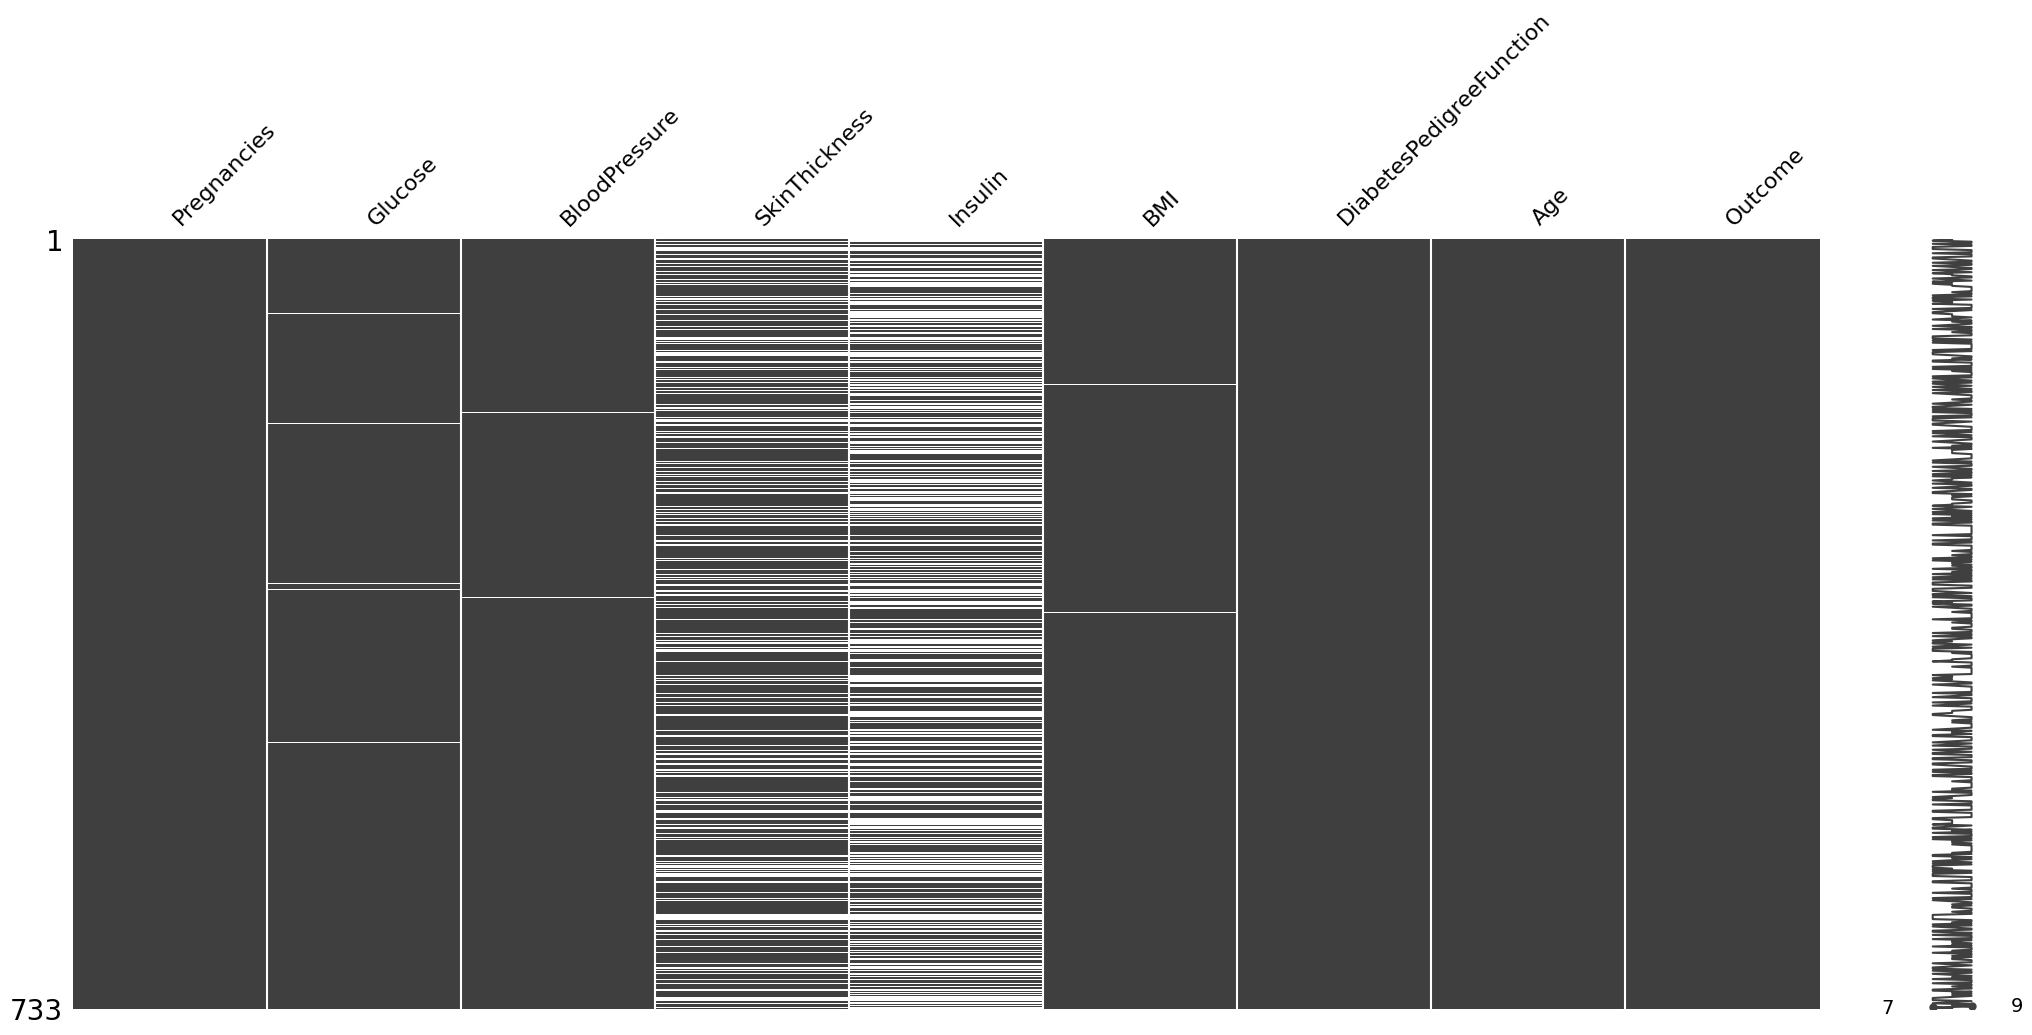

In [ ]:
msno.matrix(df)

Despues corroborar tanto con código los porcentajes y con la matriz el apartado visual, se decide eliminar la columna completa de insulin ya que a pesar de su utilidad clínica su imputación es inviable.

In [ ]:
df.drop(columns=["Insulin"], inplace=True)

/tmp/ipykernel_700/1562891960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Insulin"], inplace=True)


## 4. División train/test

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# 5. Outliers

In [ ]:
# 1. Lista de columnas (aseguramos que el orden sea consistente)
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "BMI", "DiabetesPedigreeFunction", "Age"]
X_train[columns].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
count,586.000000,582.000000,585.000000,441.000000,585.000000,586.000000,586.000000
mean,3.762799,122.518900,72.109402,29.283447,32.374530,0.480834,33.215017
std,3.402369,31.463207,12.424360,10.259538,6.867208,0.343849,11.687155
min,0.000000,44.000000,24.000000,7.000000,18.200000,0.084000,21.000000
25%,1.000000,99.250000,64.000000,22.000000,27.400000,0.241500,24.000000
50%,3.000000,118.000000,72.000000,29.000000,32.400000,0.374500,29.000000
75%,6.000000,143.000000,80.000000,36.000000,36.500000,0.644500,40.000000
max,17.000000,199.000000,122.000000,99.000000,67.100000,2.329000,81.000000


## 5.1 Graficar

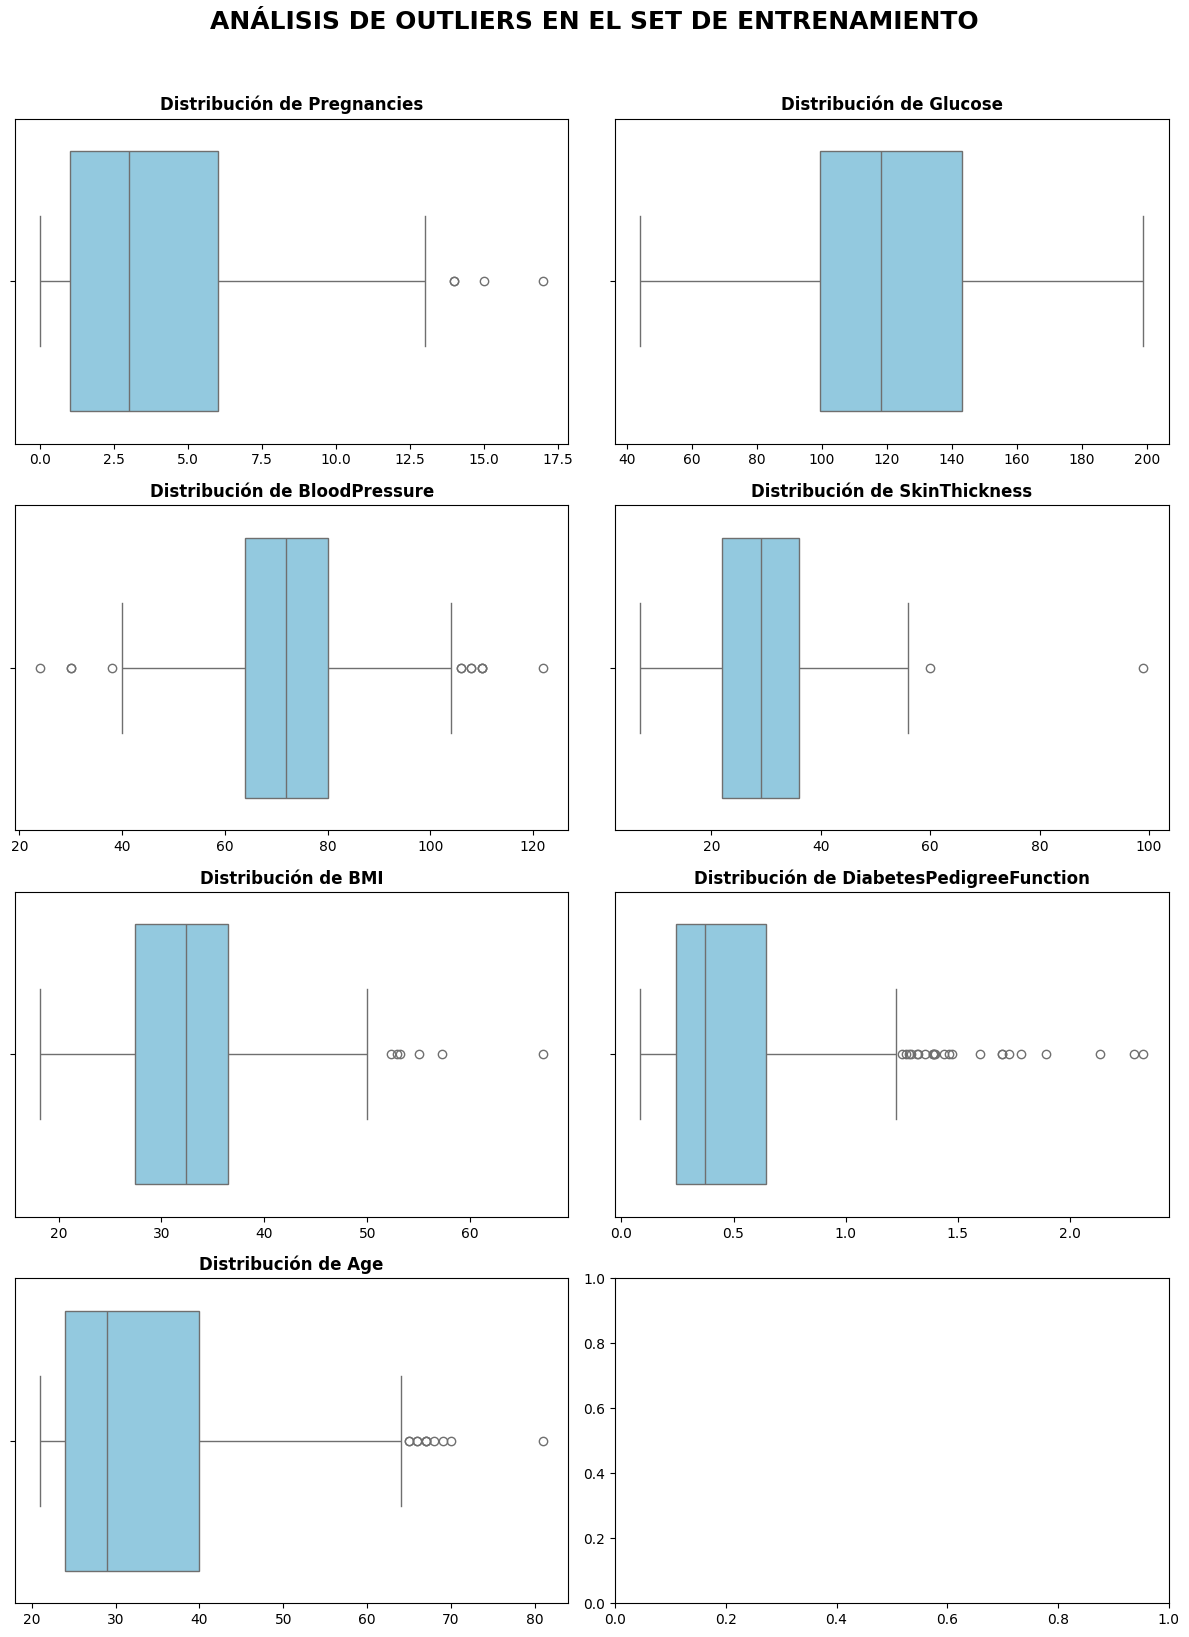

In [ ]:

# 2. Configuración de la figura (4 filas x 2 columnas)
fig, axis = plt.subplots(4, 2, figsize=(12, 16))

# 3. Rellenar los boxplots de forma automática para evitar errores manuales
# Usamos un flatten() para recorrer los ejes fácilmente del 0 al 7
for i, col in enumerate(columns):
    row = i // 2
    col_idx = i % 2
    
    sns.boxplot(ax=axis[row, col_idx], data=X_train, x=col, color="skyblue")
    axis[row, col_idx].set_title(f"Distribución de {col}", fontsize=12, fontweight="bold")
    axis[row, col_idx].set_xlabel("") # Limpiamos el label para que no se vea amontonado

# 4. Ajustes finales de estilo
fig.suptitle("ANÁLISIS DE OUTLIERS EN EL SET DE ENTRENAMIENTO", size=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Distribuciones Asimétricas a la Derecha (Right-Skewed):
Variables como DiabetesPedigreeFunction, BMI y Age presentan distribuciones asimétricas a la derecha, donde la mayoría de las observaciones se concentran en valores bajos o moderados, con una cola larga hacia valores altos. Esto indica que los valores elevados son poco frecuentes, pero clínicamente plausibles, especialmente en variables relacionadas con la diabetes.

Distribuciones Cercanas a la Normal:
Características como Glucose y BloodPressure, una vez ignorados los valores cero no válidos, muestran distribuciones más cercanas a una forma normal. Estas variables se agrupan alrededor de un valor central fisiológicamente razonable, con una dispersión relativamente equilibrada y menos valores extremos que en variables altamente sesgadas.

Outliers:
Todos los diagramas de caja evidencian la presencia de valores atípicos, siendo más notorios en DiabetesPedigreeFunction, Pregnancies y Age. No obstante, la mayoría de estos outliers representan valores reales y coherentes con el contexto clínico, reflejando la variabilidad natural de la población analizada.

Valores Cero:
Varias variables, en particular Glucose, BloodPressure, SkinThickness y BMI, contienen valores iguales a cero que no son fisiológicamente posibles. Estos ceros probablemente corresponden a datos faltantes o errores de registro, por lo que deberían tratarse como valores perdidos durante el preprocesamiento.

Distribución de la Edad:
La variable Age está sesgada hacia individuos más jóvenes, con la mayoría de los registros entre 20 y 40 años, lo que indica una población predominantemente joven. La menor representación de personas de mayor edad puede influir en el análisis y debe tenerse en cuenta al interpretar los resultados del modelo.

## 5.2 Scatter Plot con Hue

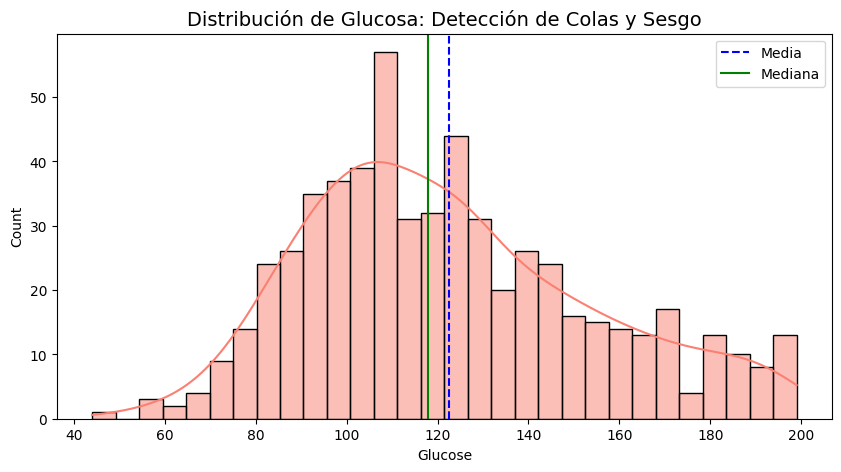

In [ ]:
# Elegimos una variable crítica como Glucose o BMI
plt.figure(figsize=(10, 5))
sns.histplot(X_train['Glucose'], kde=True, color="salmon", bins=30)
plt.axvline(X_train['Glucose'].mean(), color='blue', linestyle='--', label='Media')
plt.axvline(X_train['Glucose'].median(), color='green', linestyle='-', label='Mediana')

plt.title("Distribución de Glucosa: Detección de Colas y Sesgo", fontsize=14)
plt.legend()
plt.show()

# 6. Imputar


## 6.1 Capping

In [ ]:
# 1️Selección de variables numéricas
continuos_f = list(X_train.select_dtypes(include='number').columns)

def ajustar_outliers_train_test(train, test, columnas, allow_neg=True):
    train_c = train.copy()
    test_c = test.copy()
    limites = {}

    for col in columnas:
        q1, q3 = train_c[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        upper_lim = q3 + 1.5 * iqr
        lower_lim = q1 - 1.5 * iqr

        if not allow_neg:
            lower_lim = max(0, lower_lim)

        limites[col] = (lower_lim, upper_lim)

        train_c[col] = train_c[col].clip(lower=lower_lim, upper=upper_lim)
        test_c[col] = test_c[col].clip(lower=lower_lim, upper=upper_lim)

    return train_c, test_c

X_train_capped, X_test_capped = ajustar_outliers_train_test(
    X_train, X_test, continuos_f, allow_neg=False
)

## 6.2 Imputación iterativa 

In [ ]:
it_imputer = IterativeImputer(random_state=42)

X_train_final = pd.DataFrame(
    it_imputer.fit_transform(X_train_capped),
    columns=X_train_capped.columns,
    index=X_train_capped.index
)

X_test_final = pd.DataFrame(
    it_imputer.transform(X_test_capped),
    columns=X_test_capped.columns,
    index=X_test_capped.index
)


## 7. Selección de características

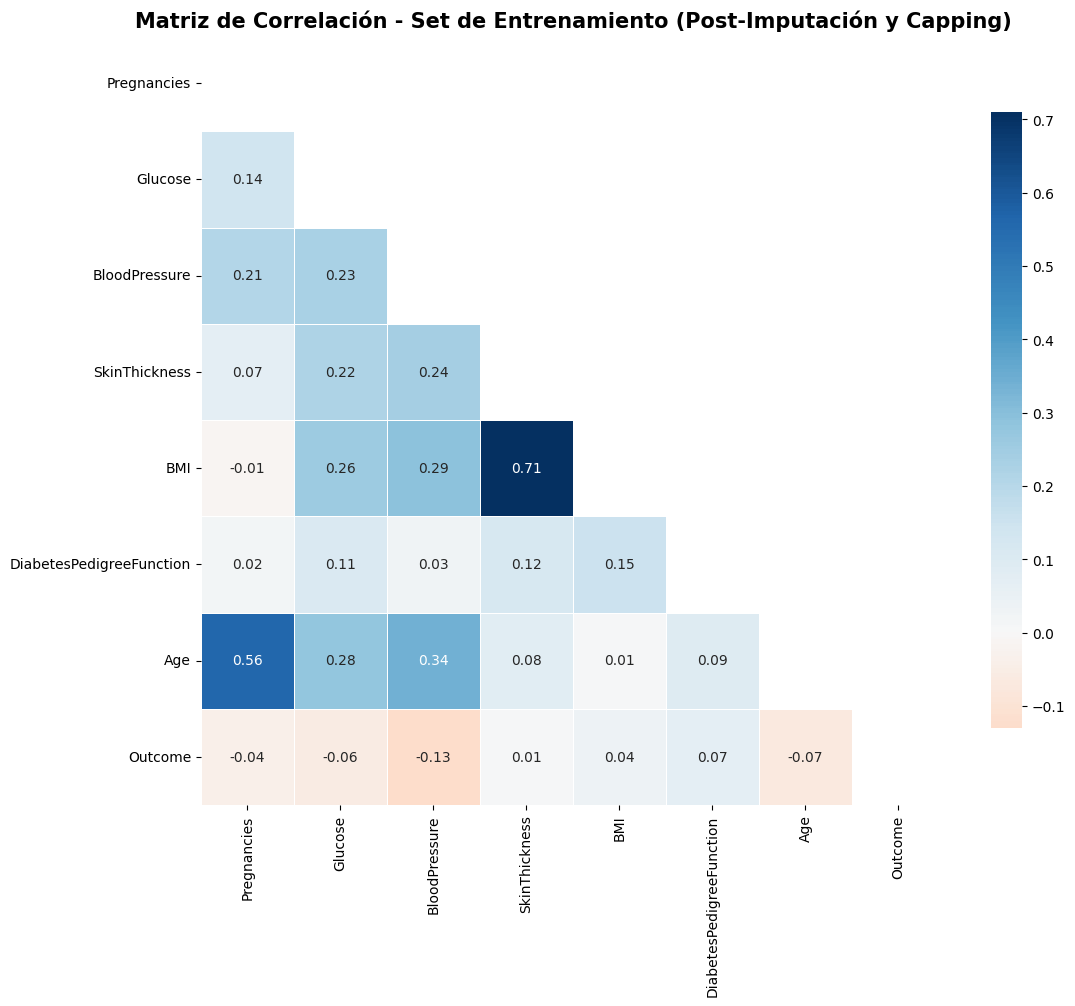

In [ ]:
train_data = X_train_final.copy()
train_data['Outcome'] = y_train.reset_index(drop=True)

corr_matrix = train_data.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    mask=mask,
    cmap='RdBu',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title(
    "Matriz de Correlación - Set de Entrenamiento (Post-Imputación y Capping)",
    fontsize=15,
    fontweight='bold'
)

plt.show()

Glucosa (0.51): Se consolida como el predictor más determinante. Su alta correlación indica que es la variable con mayor capacidad de discriminación entre las clases.

BMI (0.31) y SkinThickness (0.27): Ambas variables relacionadas con la composición corporal presentan una correlación moderada. 

Age (0.25) y Pregnancies (0.22): Factores demográficos y biológicos que muestran una influencia constante y positiva en el riesgo de padecer la enfermedad.

Pedigree Function (0.19) y BloodPressure (0.18): Son las variables con menor correlación lineal. Aunque su impacto parece marginal, se mantendrán para el entrenamiento del árbol para permitir que el algoritmo capture posibles interacciones no lineales con los predictores más fuertes.

## 7.1 Random Forest

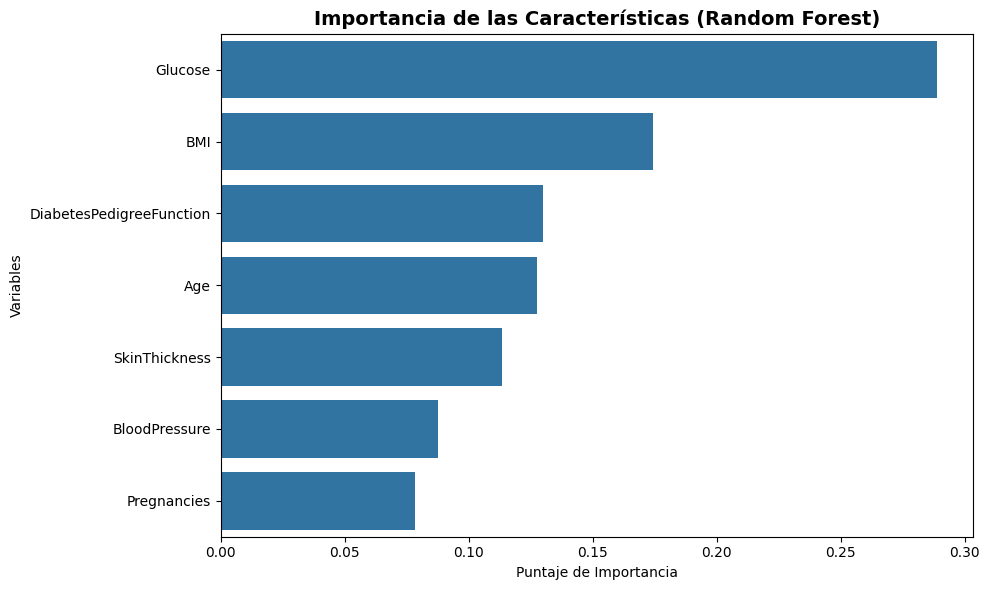


Ranking de variables:


,Característica,Importancia
0,Glucose,0.288860
1,BMI,0.174116
2,DiabetesPedigreeFunction,0.130144
3,Age,0.127690
4,SkinThickness,0.113283
5,BloodPressure,0.087681
6,Pregnancies,0.078225


In [ ]:
# 1. Instanciar el modelo
rf_model = RandomForestClassifier(
    n_estimators=200,     
    random_state=42,
    n_jobs=-1              
)

# 2. Entrenar con datos ya procesados
rf_model.fit(X_train_final, y_train.values.ravel())

# 3. Extraer importancias
feature_importance_df = (
    pd.DataFrame({
        'Característica': X_train_final.columns,
        'Importancia': rf_model.feature_importances_
    })
    .sort_values(by='Importancia', ascending=False)
    .reset_index(drop=True)
)

# 4. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x='Importancia',
    y='Característica'
)
plt.title(
    'Importancia de las Características (Random Forest)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# 5. Mostrar ranking
print("\nRanking de variables:")
display(feature_importance_df)

## 7.2 XGBoost/Permutation

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [17:19:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


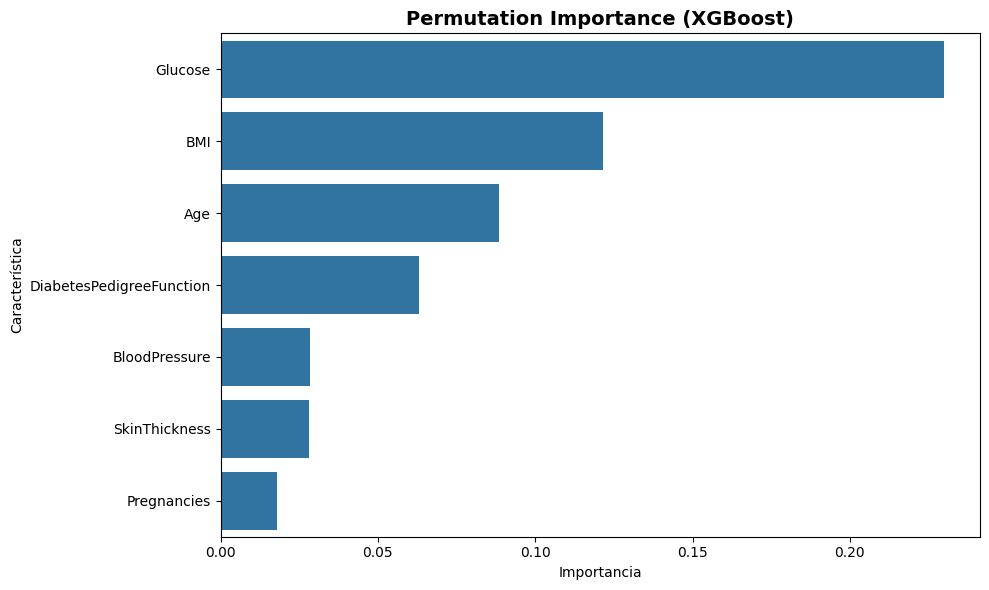


Ranking Permutation Importance:


,Característica,Importancia
0,Glucose,0.229863
1,BMI,0.121672
2,Age,0.088567
3,DiabetesPedigreeFunction,0.062969
4,BloodPressure,0.028328
5,SkinThickness,0.027986
6,Pregnancies,0.017918


In [ ]:
# 1. Modelo XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

# 2. Entrenamiento
xgb_model.fit(X_train_final, y_train.values.ravel())

# 3. Permutation Importance
perm_importance = permutation_importance(
    xgb_model,
    X_train_final,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'Característica': X_train_final.columns,
        'Importancia': perm_importance.importances_mean
    })
    .sort_values(by='Importancia', ascending=False)
    .reset_index(drop=True)
)

# 4. Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_df,
    x='Importancia',
    y='Característica'
)
plt.title(
    'Permutation Importance (XGBoost)',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nRanking Permutation Importance:")
display(perm_df)

## 7.3 Shap

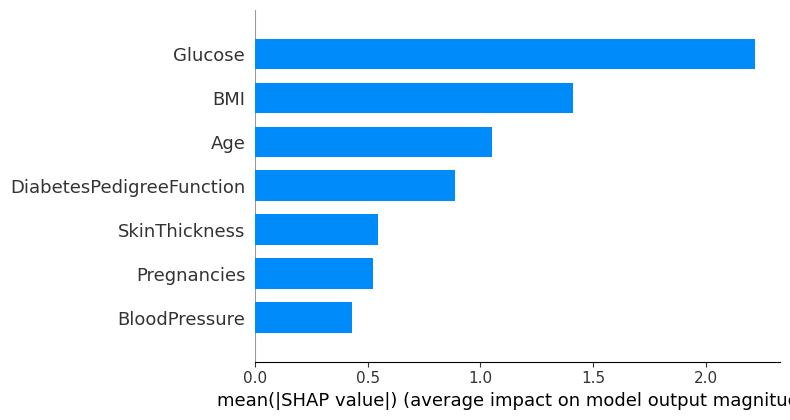

In [ ]:
# 1. Crear explainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Calcular valores SHAP
shap_values = explainer.shap_values(X_train_final)

# 3. Gráfico resumen (importancia global)
plt.figure()
shap.summary_plot(
    shap_values,
    X_train_final,
    plot_type="bar"
)

## 7.4 Comparación

In [ ]:
# 1. SHAP importancia global (media absoluta)
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'Característica': X_train_final.columns,
    'SHAP': shap_importance
})

# 2. Preparar tablas base
rf_df = feature_importance_df.rename(columns={'Importancia': 'RandomForest'})
perm_df_renamed = perm_df.rename(columns={'Importancia': 'Permutation'})

# 3. Merge de las tres fuentes
comparison_df = (
    rf_df[['Característica', 'RandomForest']]
    .merge(perm_df_renamed[['Característica', 'Permutation']], on='Característica')
    .merge(shap_df, on='Característica')
)

# 4. Normalizar (0-1) para hacerlas comparables
for col in ['RandomForest', 'Permutation', 'SHAP']:
    comparison_df[col] = comparison_df[col] / comparison_df[col].max()

# 5. Promedio global
comparison_df['Promedio'] = comparison_df[
    ['RandomForest', 'Permutation', 'SHAP']
].mean(axis=1)

# 6.Ordenar por importancia final
comparison_df = comparison_df.sort_values(
    by='Promedio',
    ascending=False
).reset_index(drop=True)

# 7. Mostrar tabla final
print("\nTabla Comparativa de Importancia:")
display(comparison_df)


Tabla Comparativa de Importancia:


,Característica,RandomForest,Permutation,SHAP,Promedio
0,Glucose,1.000000,1.000000,1.000000,1.000000
1,BMI,0.602771,0.529324,0.636937,0.589678
2,Age,0.442050,0.385301,0.473454,0.433601
3,DiabetesPedigreeFunction,0.450544,0.273942,0.400018,0.374835
4,SkinThickness,0.392171,0.121752,0.245895,0.253273
5,BloodPressure,0.303542,0.123237,0.194311,0.207030
6,Pregnancies,0.270807,0.077951,0.235990,0.194916


# 8. Machine Learning
Posterior a diferentes pruebas y siguienda la lógica de los modelos de selección el código dfinitivo es el siguiente.

In [ ]:
# 1. Definir las mejores variables según la tabla comparativa (top 5)
top_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction","SkinThickness"]

# 2. Filtrar datasets procesados
X_train_sel = X_train_final[top_features]
X_test_sel = X_test_final[top_features]

# 3. Entrenar Random Forest con top variables
rf_model_sel = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_sel.fit(X_train_sel, y_train.values.ravel())

# 4. Predicción y evaluación
y_pred = rf_model_sel.predict(X_test_sel)
accuracy = accuracy_score(y_test, y_pred)

print("Mejor Dataset: X_train_sel (Top 5 Features)")
print(f"Accuracy Score: {round(accuracy, 4)}")
print("-" * 30)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred))

Mejor Dataset: X_train_sel (Top 5 Features)
Accuracy Score: 0.7619
------------------------------
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        96
           1       0.74      0.49      0.59        51

    accuracy                           0.76       147
   macro avg       0.75      0.70      0.71       147
weighted avg       0.76      0.76      0.75       147



Clase 0 (No Diabetes): El modelo es muy bueno detectando a personas sanas, con un Recall de 0.91.

Clase 1 (Diabetes): Aquí está el reto. El Recall es de 0.49, lo que significa que el modelo identifica correctamente al 49% de las personas que realmente tienen diabetes.

Precisión de Clase 1: Cuando el modelo dice que alguien tiene diabetes, acierta el 74% de las veces.

## 8.1 Optimización

In [ ]:
# 1. Definir el grid de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Configurar la búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Entrenar buscando los mejores hiperparámetros
grid_search.fit(X_train_sel, y_train.values.ravel())

# 4. Mostrar resultados
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor Accuracy en validación: {round(grid_search.best_score_, 4)}")

Mejores parámetros encontrados:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Mejor Accuracy en validación: 0.7901


## 8.2 Entrenamiento del Modelo Definitivo

In [ ]:
# Configurar el modelo con los mejores parámetros encontrados en GridSearch
best_rf_model = RandomForestClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entrenar con el set seleccionado (Top 5 features)
best_rf_model.fit(X_train_sel, y_train.values.ravel())

# Predicciones finales sobre el set de test
y_pred_final = best_rf_model.predict(X_test_sel)

print("Modelo final optimizado entrenado.")
print(f"Accuracy en Test: {round(accuracy_score(y_test, y_pred_final), 4)}")
print("-" * 30)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred_final))

Modelo final optimizado entrenado.
Accuracy en Test: 0.7483
------------------------------
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.91      0.82        96
           1       0.72      0.45      0.55        51

    accuracy                           0.75       147
   macro avg       0.74      0.68      0.69       147
weighted avg       0.74      0.75      0.73       147



## 8.3 Optimización alternativa

In [ ]:
# 1. Definir grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. GridSearch optimizando recall
grid_search_recall = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# 3. Entrenar
grid_search_recall.fit(X_train_sel, y_train.values.ravel())

print("Mejores parámetros encontrados (optimizando recall):")
print(grid_search_recall.best_params_)
print(f"Mejor Recall en validación: {round(grid_search_recall.best_score_, 4)}")

Mejores parámetros encontrados (optimizando recall):
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Mejor Recall en validación: 0.677


In [ ]:
# Modelo con mejores parámetros (ya optimizado por recall)
best_rf_recall = grid_search_recall.best_estimator_

# Predicciones en test
y_pred_recall = best_rf_recall.predict(X_test_sel)

print("Modelo optimizado para Recall")
print(f"Accuracy en Test: {round(accuracy_score(y_test, y_pred_recall), 4)}")
print("-" * 30)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred_recall))

Modelo optimizado para Recall
Accuracy en Test: 0.7483
------------------------------
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        96
           1       0.68      0.51      0.58        51

    accuracy                           0.75       147
   macro avg       0.73      0.69      0.70       147
weighted avg       0.74      0.75      0.74       147



#### El modelo mejorado por recall brinda un mejor balance.

## 8.4 Evaluación Médica: Matriz de Confusión

<Figure size 800x600 with 0 Axes>

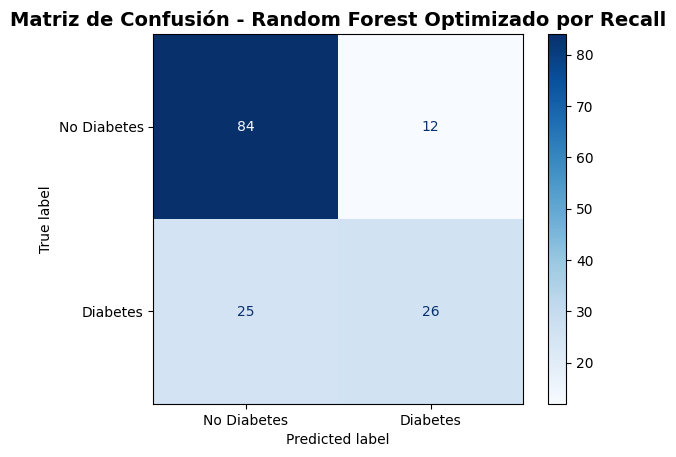

Informe Final de Clasificación (Modelo Optimizado por Recall):
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        96
           1       0.68      0.51      0.58        51

    accuracy                           0.75       147
   macro avg       0.73      0.69      0.70       147
weighted avg       0.74      0.75      0.74       147



In [ ]:
# Crear la matriz de confusión usando el modelo optimizado por recall
cm = confusion_matrix(y_test, y_pred_recall)

# Graficar de forma profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Diabetes', 'Diabetes']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Random Forest Optimizado por Recall', 
          fontsize=14, fontweight='bold')
plt.show()

# Informe detallado
print("Informe Final de Clasificación (Modelo Optimizado por Recall):")
print(classification_report(y_test, y_pred_recall))

# Apartado, modelos gráficos para visualización

In [ ]:
# 1. Entrenamos el árbol usando las variables seleccionadas (Top 5)
tree_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    criterion='entropy',
    random_state=42
)

tree_model.fit(X_train_sel, y_train.values.ravel())

# 2. Generamos las reglas completas del árbol
tree_rules = export_text(
    tree_model,
    feature_names=list(X_train_sel.columns),
    max_depth=100
)

# 3. Guardar en archivo
with open("arbol_reglas_completas.txt", "w") as f:
    f.write(tree_rules)

# 4. Imprimir en pantalla
print(tree_rules)

print("\n--- PROCESO FINALIZADO ---")
print("Si el texto aparece truncado en consola, abre el archivo 'arbol_reglas_completas.txt'.")

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 24.50
|   |   |   |--- BMI <= 33.25
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  33.25
|   |   |   |   |--- SkinThickness <= 37.55
|   |   |   |   |   |--- Glucose <= 113.50
|   |   |   |   |   |   |--- Age <= 21.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Age >  21.50
|   |   |   |   |   |   |   |--- Glucose <= 90.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Glucose >  90.00
|   |   |   |   |   |   |   |   |--- Glucose <= 96.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- Glucose >  96.50
|   |   |   |   |   |   |   |   |   |--- SkinThickness <= 28.49
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- SkinThickness >  28.49
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Glucose >  113.50

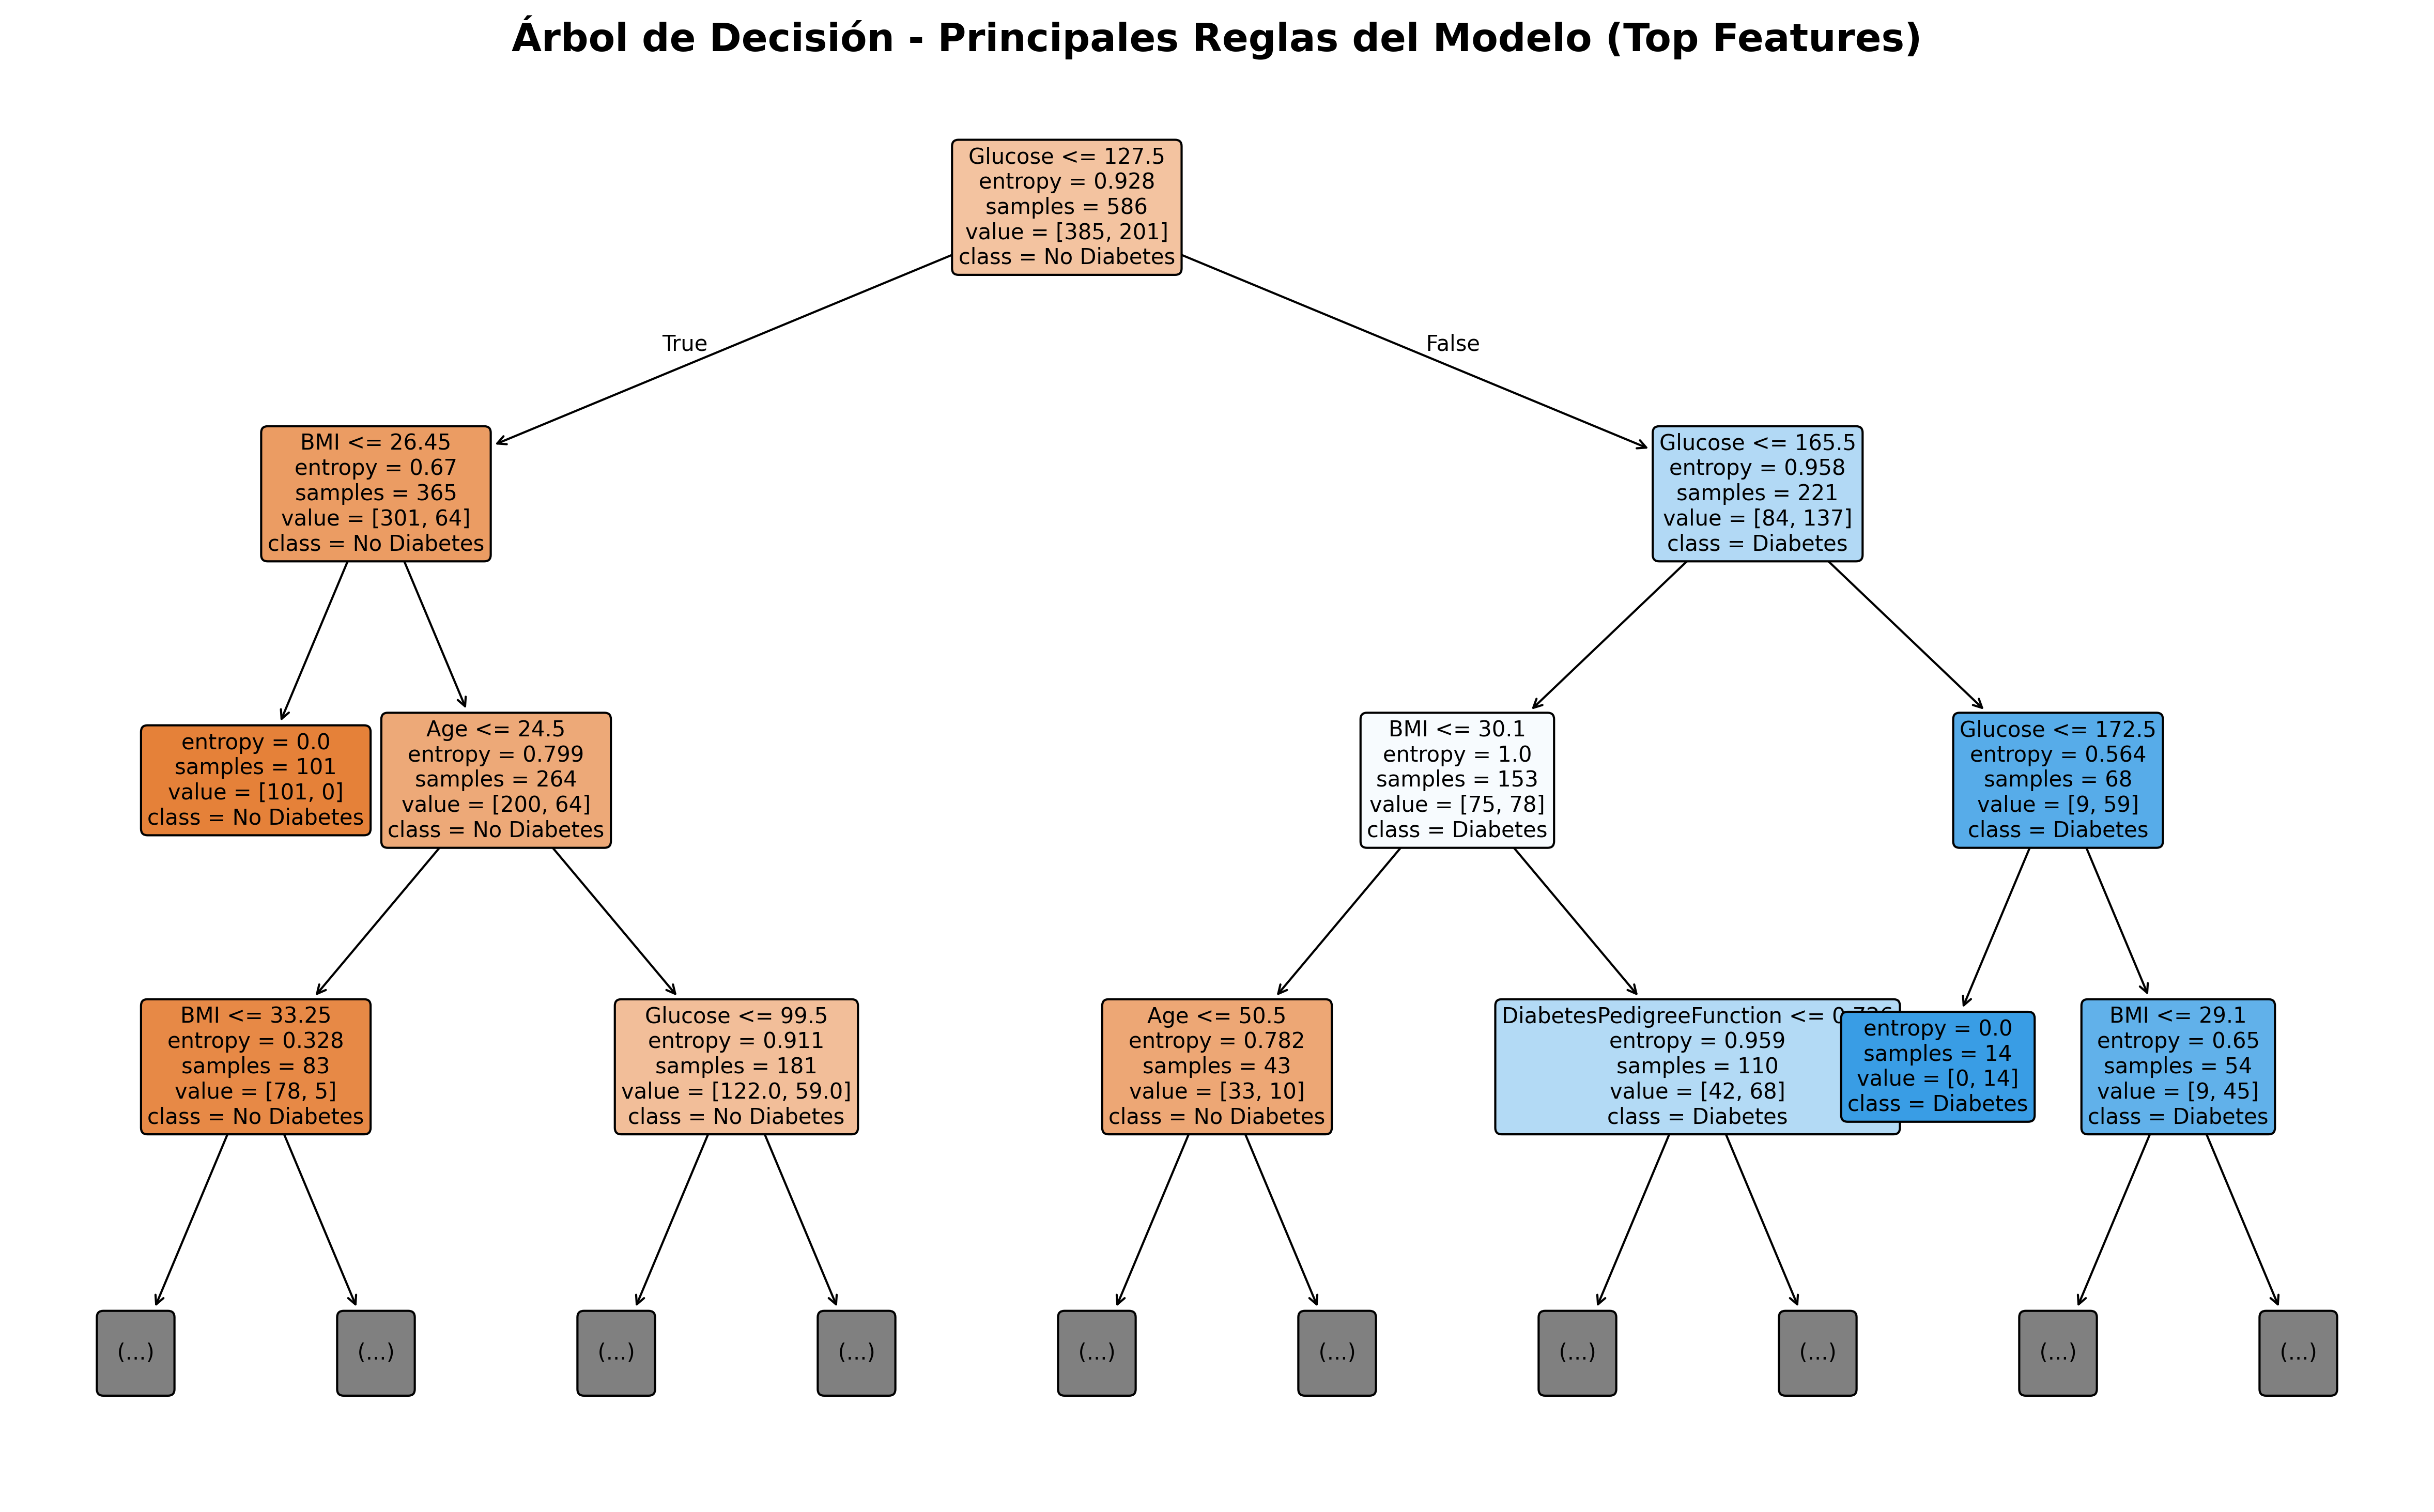

In [ ]:
# 1. Definimos el tamaño de la figura
plt.figure(figsize=(20, 12), dpi=300)

# 2. Visualización del árbol entrenado
plot_tree(
    tree_model,
    feature_names=list(X_train_sel.columns),
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Solo mostramos los niveles principales para interpretación
)

# 3. Título y visualización
plt.title(
    "Árbol de Decisión - Principales Reglas del Modelo (Top Features)",
    fontsize=18,
    fontweight='bold'
)

plt.show()

# 11 Guardar modelo

In [ ]:
# Crear carpeta si no existe
os.makedirs('../models/', exist_ok=True)

# Guardar el modelo optimizado por recall usando pickle
model_path = '../models/random_forest_diabetes_recall_optimized_v1.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_rf_recall, f)

print(f"Modelo optimizado guardado exitosamente en {model_path}")

Modelo optimizado guardado exitosamente en ../models/random_forest_diabetes_recall_optimized_v1.pkl


In [ ]:
# Ruta de guardado
processed_path = "/workspaces/steven10015-intro-ml/data/processed"
os.makedirs(processed_path, exist_ok=True)

# Unimos features seleccionadas + target
train_data = pd.concat([X_train_sel, y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test_sel, y_test.reset_index(drop=True)], axis=1)

# Guardar
train_data.to_csv(f"{processed_path}/train_selected_features.csv", index=False)
test_data.to_csv(f"{processed_path}/test_selected_features.csv", index=False)

print(f"Datasets finales guardados en: {processed_path}")

Datasets finales guardados en: /workspaces/steven10015-intro-ml/data/processed
